# When does trend work

The 4-week trend book on crypto coins trading at least \$10M a day does not earn evenly across years. A signal that misses the pooled bar can still pass inside one market condition, a condition that is known before the trade and occurs often enough to matter.

This notebook looks for that condition. Six candidates, each measured only from the past.

- Co-movement. How tightly liquid coins moved together over the last 12 weeks, as their average pairwise correlation.
- Market volatility. The liquid market's weekly volatility over the last 12 weeks.
- Trend strength. The size of the market's last 4-week move measured in its own volatility.
- Funding. Average funding across liquid coins over the last 4 weeks.
- Dispersion. How spread out coins' last 4-week returns are.
- Market direction. Whether the market rose or fell over the last 4 weeks.

Each is cut into low, mid and high thirds. The cut points come only from weeks before the one being sorted, so no week is sorted with future information.

The map is a search over the full sample. Every result is split into the earlier 60% of weeks and the later 40%, but both halves are looked at here, so the later one is a consistency check and not a holdout. Whatever the map turns up is exploratory.

## Setup

Load the panel and the shared book. Build the per coin and market books at 4 weeks on \$10M coins with the provisional costs, the long and short basket, and the long and short sides of the per coin book. Then build the six conditions and their thirds.

In [9]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from book import Book, halves, sharpe
import stream

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2})
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#8a8a86'

tb = Book()
W, R, LIQ, VOL, F = tb.W, tb.R, tb.LIQ, tb.VOL, tb.F
run, sized = tb.run, tb.sized

liquid = LIQ >= 1e7
market_ret = tb.market_ret()
basket = tb.basket()
per_coin_w, market_w = tb.per_coin(4), tb.market(4)
per_coin, market = run(per_coin_w).net, run(market_w).net
long_basket, short_basket = run(basket).net, run(-basket).net
long_leg, short_leg = run(per_coin_w.clip(lower=0)).net, run(per_coin_w.clip(upper=0)).net

def sleeve(on, w=None, **kw):
    return tb.sleeve(per_coin_w if w is None else w, on, **kw)

idx = per_coin.index
train = halves(idx)

cond = tb.conditions()
labels = tb.labels(cond, idx)
BUCKET = {0: 'low', 1: 'mid', 2: 'high'}
print('median of each condition by year')
print(cond.groupby(cond.index.year).median().round(3).T)

median of each condition by year
day                2020   2021   2022   2023   2024   2025   2026
co-movement       0.486  0.495  0.660  0.628  0.585  0.673  0.462
market vol        0.095  0.135  0.122  0.095  0.115  0.123  0.075
trend strength    0.883  0.879  0.851  0.666  0.619  0.905  0.960
funding           0.002  0.005 -0.001  0.001  0.001 -0.002 -0.007
dispersion        0.174  0.313  0.164  0.148  0.202  0.258  0.401
market direction  1.000  1.000 -1.000  1.000 -1.000 -1.000 -1.000


2026 is unlike any earlier year. It has the lowest co-movement, 0.46, the lowest market volatility, 0.075 a week, and the highest dispersion, 0.40. Coins stopped moving as a pack, the market went quiet, and individual coins scattered.

Market direction here is the median of $+1$ or $-1$, so it only says whether most weeks followed a rise or a fall.

## The map

Net Sharpe of the per coin book in each third of each condition, over all weeks, the earlier weeks and the later weeks, with the share of weeks each third holds. A condition is only interesting if the earlier and later weeks agree.

per coin, all weeks   0.85   earlier 1.04   later 0.55
                         all  earlier  later  share of weeks
condition        third                                      
co-movement      low    0.93     0.28   1.24            0.23
                 mid   -0.01    -0.09   0.05            0.29
                 high   1.15     1.43   0.58            0.29
market vol       low    0.56     0.24   0.88            0.35
                 mid    0.68     0.58   0.84            0.28
                 high   0.60     1.24  -0.07            0.21
trend strength   low    1.62     1.22   2.20            0.29
                 mid    0.57     0.82   0.25            0.29
                 high   0.02     0.06  -0.01            0.26
funding          low    0.07     0.21  -0.06            0.45
                 mid    0.78     0.86   0.65            0.29
                 high   1.96     1.47   2.68            0.12
dispersion       low    0.47     0.46   0.50            0.24
                 mid    1.03  

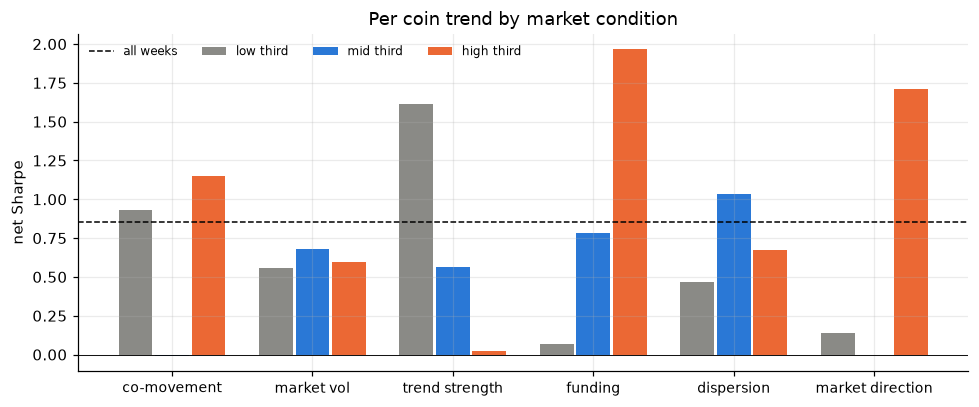

In [10]:
def cond_map(net):
    rows = []
    for k, lab in labels.items():
        for v in [0, 1, 2]:
            m = lab == v
            if m.sum() == 0:
                continue
            rows.append({'condition': k, 'third': BUCKET[v], 'all': sharpe(net[m]), 'earlier': sharpe(net[m & train]),
                         'later': sharpe(net[m & ~train]), 'share of weeks': m.mean()})
    return pd.DataFrame(rows).set_index(['condition', 'third'])

print(f'per coin, all weeks   {sharpe(per_coin):.2f}   earlier {sharpe(per_coin[train]):.2f}   later {sharpe(per_coin[~train]):.2f}')
print(cond_map(per_coin).round(2))
print()
print(f'market book, all weeks   {sharpe(market):.2f}   earlier {sharpe(market[train]):.2f}   later {sharpe(market[~train]):.2f}')
print(cond_map(market).round(2))

cm = cond_map(per_coin)
fig, ax = plt.subplots(figsize=(9, 3.8))
conds = list(labels)
x = np.arange(len(conds)); wd = 0.26
for i, (t, colour) in enumerate([('low', GREY), ('mid', BLUE), ('high', ORANGE)]):
    vals = [cm.loc[(c, t), 'all'] if (c, t) in cm.index else np.nan for c in conds]
    ax.bar(x + (i - 1) * wd, vals, width=wd - 0.02, color=colour, label=f'{t} third')
ax.axhline(sharpe(per_coin), color='k', ls='--', lw=1, label='all weeks')
ax.axhline(0, color='k', lw=0.6)
ax.set_xticks(x); ax.set_xticklabels(conds, fontsize=9); ax.set_ylabel('net Sharpe')
ax.set_title('Per coin trend by market condition'); ax.legend(frameon=False, ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

Two conditions agree between the earlier and later weeks, in both books.

- Market direction. After the market rose over the last 4 weeks, per coin trend makes 1.71, with 1.88 earlier and 1.30 later. After it fell, 0.14.
- Trend strength. When the market's last 4-week move was small against its volatility, per coin trend makes 1.62, with 1.22 earlier and 2.20 later. After a large move, 0.02.

High funding scores 1.96 but holds only 12% of weeks. The rest disagree between the halves or change little across thirds. Low co-movement, the obvious suspect for 2026, is weak earlier at 0.28 and strong later at 1.24.

This map is 34 cells across two books, so single cells need the same caution as any grid.

## Is it trend, or just being long or short

After a rise the book is mostly long, and after a fall mostly short, so its profit there could simply be the market moving. Compare the same weeks with holding the basket long and holding it short, and split the book into its long and short sides. Do the same for trend strength.

In [11]:
direction, strength = labels['market direction'], labels['trend strength']
rows = []
for name, m in [('after a rise', direction == 2), ('after a fall', direction == 0),
                ('trend strength low', strength == 0), ('trend strength mid', strength == 1), ('trend strength high', strength == 2)]:
    rows.append({'weeks': name, 'per coin': sharpe(per_coin[m]), 'long basket': sharpe(long_basket.reindex(idx)[m]), 'short basket': sharpe(short_basket.reindex(idx)[m]),
                 'long side': sharpe(long_leg[m]), 'short side': sharpe(short_leg[m]), 'count': int(m.sum())})
print(pd.DataFrame(rows).set_index('weeks').round(2))
print()
print('direction by strength, per coin net Sharpe and share of weeks')
print(pd.DataFrame({d: {BUCKET[v]: f'{sharpe(per_coin[(direction == dv) & (strength == v)]):+.2f} ({((direction == dv) & (strength == v)).mean():.0%})'
                        for v in [0, 1, 2]} for d, dv in [('after a rise', 2), ('after a fall', 0)]}).T)

                     per coin  long basket  short basket  long side  \
weeks                                                                 
after a rise             1.71         1.55         -1.56       1.72   
after a fall             0.14        -0.22          0.20      -0.20   
trend strength low       1.62        -0.92          0.90      -0.26   
trend strength mid       0.57         0.84         -0.86       1.28   
trend strength high      0.02         0.75         -0.77       0.63   

                     short side  count  
weeks                                   
after a rise              -0.62    146  
after a fall               0.19    190  
trend strength low         1.37     98  
trend strength mid        -0.28     98  
trend strength high       -0.51     88  

direction by strength, per coin net Sharpe and share of weeks
                      low          mid         high
after a rise  +1.21 (15%)   +2.62 (9%)   +0.79 (9%)
after a fall  +2.04 (14%)  -0.27 (21%)  -0.46 (1

After a rise, holding the basket long makes 1.55, almost as much as trend's 1.71. The long side makes 1.72 and the short side loses $-0.62$. This condition is mostly rallies continuing, and being long captures it. After a fall, the short side earns only 0.19. Rises continue, falls barely do, which matches the tails, where big moves lean up.

Trend strength is different, though less than it first looks. When the last month's move was small, holding the basket long loses $-0.92$ and trend makes 1.62, with the profit from the short side at 1.37. But holding the basket short over the same weeks makes 0.90, so much of that profit is being short while the market drifts down. The signal's lift over the short basket is 0.72. After a large move trend earns nothing.

The best combinations are a small fall, 2.04 over 14% of weeks, and a rise of middling strength, 2.62 over 9%. Middling and large falls lose.

## Year by year inside the condition

A conditional pass needs the condition to work consistently. Split the per coin book's weeks inside each condition by year. Then trade only inside the condition and sit flat otherwise, and read that book by year.

In [12]:
inside = {}
for name, m in [('after a rise', direction == 2), ('trend strength low', strength == 0), ('all weeks', pd.Series(True, index=idx))]:
    x = per_coin[m]
    inside[name] = {y: f'{sharpe(g):+.2f} ({len(g)})' for y, g in x.groupby(x.index.year)}
print('net Sharpe inside the condition by year (weeks)')
print(pd.DataFrame(inside).T)
print()
for name, m in [('after a rise', direction == 2), ('trend strength low', strength == 0)]:
    g = run(per_coin_w.where(m.reindex(per_coin_w.index).fillna(False).astype(bool), 0.0)).net
    print(f'{name:19} traded only inside   Sharpe {sharpe(g):+.2f}   return {g.mean() * 5200:+.1f}% a year   by year',
          {y: round(sharpe(v), 2) for y, v in g.groupby(g.index.year)})
print(f'{"always on":19}                      Sharpe {sharpe(per_coin):+.2f}   return {per_coin.mean() * 5200:+.1f}% a year')

net Sharpe inside the condition by year (weeks)
                          2020        2021        2022        2023  \
after a rise        +1.46 (24)  +3.37 (35)  -1.09 (14)  +2.38 (27)   
trend strength low         NaN  +2.03 (15)  +3.41 (18)  +0.13 (18)   
all weeks           +1.07 (39)  +1.70 (52)  +0.80 (52)  +0.83 (53)   

                          2024        2025        2026  
after a rise        +1.54 (25)  +1.13 (12)   -1.26 (9)  
trend strength low  +1.19 (22)  +3.83 (15)  +1.07 (10)  
all weeks           +0.25 (52)  +1.16 (52)  -0.65 (36)  

after a rise        traded only inside   Sharpe +1.10   return +41.0% a year   by year {2020: np.float64(1.16), 2021: np.float64(2.66), 2022: np.float64(-0.57), 2023: np.float64(1.65), 2024: np.float64(1.04), 2025: np.float64(0.54), 2026: np.float64(-0.64)}
trend strength low  traded only inside   Sharpe +0.91   return +19.9% a year   by year {2021: np.float64(1.28), 2022: np.float64(1.8), 2023: np.float64(0.03), 2024: np.float64(0.74), 2

After a rise is not consistent. It loses in 2022 and 2026.

Low trend strength is. It is positive in every year it covers, 2021 to 2026, though near flat in 2023 at 0.13. 2020 has no label because the cut points need a year of history first.

Trading only after a rise lifts the Sharpe from 0.85 to 1.10 at nearly the same return, because it drops the weeks that earned little. Trading only when trend strength is low makes 0.91 and is positive every year, but earns far less, 20% a year against 45%, since it sits out most weeks.

## Can any condition rescue 2026

Sort just the 2026 weeks into the same thirds.

In [13]:
in_2026 = idx.year == 2026
rows = {}
for k, lab in labels.items():
    rows[k] = {BUCKET[v]: f'{sharpe(per_coin[in_2026 & (lab == v)]):+.2f} ({int((in_2026 & (lab == v)).sum())})'
               for v in [0, 1, 2] if (in_2026 & (lab == v)).sum() > 1}
print('2026 only, per coin net Sharpe by third (weeks)')
print(pd.DataFrame(rows).T.fillna(''))
print(f'2026 mean weekly net {per_coin[in_2026].mean() * 1e4:+.1f} bps   worst week {per_coin[in_2026].min():+.3f}')

2026 only, per coin net Sharpe by third (weeks)
                         low         mid        high
co-movement       -0.65 (36)                        
market vol        -0.65 (36)                        
trend strength    +1.07 (10)  -0.19 (10)  -1.92 (16)
funding           -0.58 (32)   -1.11 (4)            
dispersion                                -0.17 (35)
market direction  -0.41 (27)               -1.26 (9)
2026 mean weekly net -42.7 bps   worst week -0.117


All 36 weeks of 2026 fall in the lowest third of co-movement and of market volatility, and 35 of them in the highest third of dispersion. Those conditions put all of 2026 in one corner, so they cannot separate it.

Trend strength does. The 2026 weeks after a small move made 1.07, those after a middling move $-0.19$ and those after a large move $-1.92$. The year's loss came from weeks after big market moves. The book lost 43 bps a week on average in 2026, with a worst week of $-11.7\%$.

## Open interest

Open interest is the total size of open perp positions, a direct read on leverage. The forced deleveraging idea says trend feeds on leverage, since liquidations push price further in the direction it is already moving.

Open interest in dollars rises just because price rises, so measure it in contracts instead, dollar open interest over price, summed across BTC, ETH, SOL, BNB, XRP and DOGE. Two conditions, both from past weeks only. Its growth over the last 4 weeks, and its level against its own 26-week average, each cut into thirds on earlier weeks.

In [14]:
majors = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT']
oi = stream.open_interest(majors, '2020-09-01', '2026-09-01')
print('coverage from', {s: str(oi[s].first_valid_index().date()) for s in majors})
log_oi = np.log(oi.resample('W-SUN').last().reindex(W.index))
log_contracts = log_oi.sub(W[majors].cumsum(), axis=0)
oi_cond = {'OI growth, 4 weeks': log_contracts.diff(4).mean(axis=1).shift(1),
           'OI level vs 26-week average': (log_contracts - log_contracts.rolling(26, min_periods=13).mean()).mean(axis=1).shift(1)}
rows = []
for k, v in oi_cond.items():
    lab = tb.thirds(v).reindex(idx)
    for t in [0, 1, 2]:
        m = lab == t
        rows.append({'condition': k, 'third': BUCKET[t], 'all': sharpe(per_coin[m]), 'earlier': sharpe(per_coin[m & train]),
                     'later': sharpe(per_coin[m & ~train]), 'weeks': int(m.sum())})
print(pd.DataFrame(rows).set_index(['condition', 'third']).round(2))
print()
print('correlation with the other conditions')
print(pd.DataFrame({**oi_cond, 'trend strength': cond['trend strength'], 'market direction': cond['market direction']}).corr().round(2))

coverage from {'BTCUSDT': '2020-09-01', 'ETHUSDT': '2021-12-01', 'SOLUSDT': '2021-12-01', 'BNBUSDT': '2021-12-01', 'XRPUSDT': '2021-12-01', 'DOGEUSDT': '2021-12-01'}
                                    all  earlier  later  weeks
condition                   third                             
OI growth, 4 weeks          low   -0.12    -0.89   0.37     52
                            mid    1.05     0.87   1.12     99
                            high   0.53     2.36  -0.18     57
OI level vs 26-week average low   -1.40    -1.85  -1.27     57
                            mid    1.68     1.10   2.04     70
                            high   0.84     1.18   0.78     64

correlation with the other conditions
                             OI growth, 4 weeks  OI level vs 26-week average  \
OI growth, 4 weeks                         1.00                         0.64   
OI level vs 26-week average                0.64                         1.00   
trend strength                            -0.27    

Growth in open interest says nothing reliable. Its thirds disagree between the earlier and later weeks.

Its level does. When open interest sits below its recent average, after the market has shed leverage, trend loses, $-1.40$ over all weeks, $-1.85$ earlier and $-1.27$ later. At middling and high levels it earns, 1.68 and 0.84. That fits the leverage idea from the other side. Trend needs leverage in the market to feed its moves.

The evidence is thin. Open interest for five of the six majors starts in December 2021, and the thirds need a year of history, so the labels cover about 190 weeks from late 2022, around 60 per third. It is only loosely tied to trend strength, a correlation of $-0.21$, so it carries mostly separate information.

## Is low trend strength robust

It was found by looking, so shake it. Move the cut point to a quarter and a half. Measure the move over 2, 4 and 8 weeks and the volatility over 8, 12 and 26. Apply it to the other lookbacks of the per coin book. Shorten the warm-up so 2020 gets labels. Rerun at twice cost. Every variant is the sleeve with its switching cost charged.

In [15]:
def small_move(n_ret=4, n_vol=12, q=1 / 3, min_hist=52):
    x = (market_ret.rolling(n_ret).sum().abs() / (market_ret.rolling(n_vol, min_periods=8).std() * np.sqrt(n_ret))).shift(1)
    out = pd.Series(np.nan, index=x.index)
    for i in range(len(x)):
        past = x.iloc[:i].dropna()
        if len(past) >= min_hist and not np.isnan(x.iloc[i]):
            out.iloc[i] = float(x.iloc[i] <= past.quantile(q))
    return out.reindex(idx)

def split(s):
    tr = train.reindex(s.index).fillna(False).astype(bool)
    y = s.groupby(s.index.year).apply(sharpe).dropna()
    return {'sleeve': sharpe(s), 'earlier': sharpe(s[tr]), 'later': sharpe(s[~tr]), 'years positive': f'{int((y > 0).sum())} of {len(y)}'}

rows = []
for q in [0.25, 1 / 3, 0.5]:
    m = small_move(q=q) == 1
    rows.append({'variant': f'cut at {q:.0%}', **split(sleeve(m)), 'weeks': m.mean()})
for nr in [2, 4, 8]:
    for nv in [8, 12, 26]:
        m = small_move(nr, nv) == 1
        rows.append({'variant': f'{nr}w move, {nv}w vol', **split(sleeve(m)), 'weeks': m.mean()})
print(pd.DataFrame(rows).set_index('variant').round(2))
print()

base = small_move() == 1
labelled = small_move().notna()
for L in [1, 2, 3, 4, 5, 6, 8, 12]:
    wL = sized(np.sign(W.rolling(L, min_periods=L).sum()).shift(1), 1e7)
    nL = run(wL).net.reindex(idx)
    print(f'per coin L={L:2d}   sleeve {sharpe(sleeve(base, wL)):+.2f}   outside {sharpe(nL[~base & labelled]):+.2f}')
print(f'market L= 4   sleeve {sharpe(sleeve(base, market_w)):+.2f}   outside {sharpe(market[~base & labelled]):+.2f}')
print()
se = sleeve(small_move(min_hist=26) == 1)
print('26-week warm-up, by year', {y: f'{sharpe(g):+.2f} ({len(g)})' for y, g in se.groupby(se.index.year)})
print(f'sleeve at twice cost {sharpe(sleeve(base, cost_mult=2.0)):+.2f}')

                  sleeve  earlier  later years positive  weeks
variant                                                       
cut at 25%          1.11     0.81   1.64         5 of 6   0.21
cut at 33%          1.56     1.16   2.15         6 of 6   0.29
cut at 50%          0.73     0.40   1.16         5 of 6   0.43
2w move, 8w vol     1.50     1.62   1.35         6 of 6   0.25
2w move, 12w vol    1.91     1.93   1.88         6 of 6   0.24
2w move, 26w vol    2.65     2.95   2.22         5 of 6   0.23
4w move, 8w vol     1.39     1.01   1.87         6 of 6   0.30
4w move, 12w vol    1.56     1.16   2.15         6 of 6   0.29
4w move, 26w vol    1.40     1.04   1.96         6 of 6   0.29
8w move, 8w vol     0.99     0.83   1.21         5 of 6   0.33
8w move, 12w vol    1.26     1.17   1.40         5 of 6   0.33
8w move, 26w vol    1.14     1.17   1.09         3 of 6   0.30

per coin L= 1   sleeve +1.73   outside -0.39
per coin L= 2   sleeve +0.90   outside -0.45
per coin L= 3   sleeve +0.2

The window barely matters. Every 2 and 4 week move with every volatility window stays positive earlier and later, 1.35 to 2.22 in the later weeks, and all but one are positive in all six years. An 8 week move weakens it.

The lookback matters more. Inside the condition per coin trend earns at every lookback, but 3 weeks makes only 0.23 against 1.56 at 4 and 1.55 at 5, the same hole as the always-on grid. The best inside is the one-week lookback, 1.73. Outside the condition per coin trend loses at every lookback except 4 weeks, which keeps 0.29. The market book makes 1.64 inside and 0.12 outside.

With a shorter warm-up, 2020 is labelled and positive too. At twice cost the sleeve makes 1.42.

The cut point is the weak spot. Thirds work best. A quarter falls to 1.11 and a half to 0.73, each losing one year.

## The sleeve, costed

Trading the condition means entering when it turns on and exiting when it turns off. Charge those trades to the sleeve, and set it against the same weeks without the switching cost, against holding the basket long and holding it short over the same weeks, and against the always-on book.

In [16]:
on = base.reindex(idx).fillna(False).astype(bool)
s = sleeve(base)
tr = train.reindex(s.index).fillna(False).astype(bool)
switches = int((on.astype(int).diff().abs() == 1).sum())
print(f'sleeve {len(s)} weeks, the gate switches {switches} times')
print(f'  costed sleeve             {sharpe(s):+.2f}   earlier {sharpe(s[tr]):+.2f}   later {sharpe(s[~tr]):+.2f}')
print(f'  without switching cost    {sharpe(per_coin.reindex(idx)[on]):+.2f}')
print(f'  long basket, same weeks   {sharpe(long_basket.reindex(idx)[on]):+.2f}')
print(f'  short basket, same weeks  {sharpe(short_basket.reindex(idx)[on]):+.2f}')
print(f'  always-on book            {sharpe(per_coin):+.2f}')
print('  sleeve by year', {y: f'{sharpe(g):+.2f} ({len(g)})' for y, g in s.groupby(s.index.year)})

sleeve 98 weeks, the gate switches 89 times
  costed sleeve             +1.56   earlier +1.16   later +2.15
  without switching cost    +1.62
  long basket, same weeks   -0.92
  short basket, same weeks  +0.90
  always-on book            +0.85
  sleeve by year {2021: '+2.00 (15)', 2022: '+3.28 (18)', 2023: '+0.06 (18)', 2024: '+1.15 (22)', 2025: '+3.77 (15)', 2026: '+1.03 (10)'}


Charging the entries and exits costs the sleeve 0.06, from 1.62 to 1.56 over its 98 weeks, as the gate switches 89 times. It makes 1.16 in the earlier weeks and 2.15 in the later ones, and it is positive in every year it covers, though 2023 is flat at 0.06.

Holding the basket long over the same weeks loses $-0.92$ and holding it short makes 0.90. Part of what the sleeve earns is being short while the market drifts down, and its lift over the short basket is 0.66. The always-on book makes 0.85.

## Verdict

Per coin trend earns most after a moderate market month, when the market's last 4-week move was small against its volatility. The costed sleeve makes 1.56 over 98 weeks, positive every year it covers, and the windows it is measured over barely matter.

Three things hold it back. It was found by searching this map over the full sample, so it is exploratory. Much of its profit is being short in weeks the basket falls, which the short basket makes 0.90 of. And the cut point and lookback matter more than they should, a quarter or a half weaker than thirds, and 3 weeks nearly flat where 4 and 5 earn.

After a rise is the other strong condition, but it is mostly being long in a rally and it loses in 2022 and 2026.

Open interest adds a separate warning. Trend loses when open interest in contracts sits below its recent average, in the earlier and later weeks alike, on about 190 weeks of history.